Goal: 利用 Detr 進行物件偵測任務，目前挑選番茄資料集進行偵測，判斷是否成熟。  
[Detr finetune notebook](https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/train-huggingface-detr-on-custom-dataset.ipynb)  
[Kaggle example](https://www.kaggle.com/code/kirollosashraf/tomato-fruit-detection/notebook)  
[tomatOD dataset](https://datasetninja.com/tomatod)

### Before start
The notebook annoted in previous are encouraged to train in GPU, so first check the setting.

In [1]:
!nvidia-smi

Wed Jul 16 02:13:34 2025       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 522.06       Driver Version: 522.06       CUDA Version: 11.8     |
|-------------------------------+----------------------+----------------------+
| GPU  Name            TCC/WDDM | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ... WDDM  | 00000000:01:00.0 Off |                  N/A |
| N/A   42C    P8     5W /  N/A |      0MiB /  4096MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [1]:
import os
HOME = os.getcwd()
print(HOME)

c:\Users\vlva8\OneDrive\Desktop\advML\final_projects


Download the depencies

In [3]:
!pip install -i https://test.pypi.org/simple/ supervision==0.3.0
!pip install -q transformers
!pip install -q pytorch-lightning
!pip install -q timm

Looking in indexes: https://test.pypi.org/simple/
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.1/823.1 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 61.9 MB/s eta

In [2]:
import torch
!nvcc --version
TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
CUDA_VERSION = torch.__version__.split("+")[-1]
print("torch: ", TORCH_VERSION, "; cuda: ", CUDA_VERSION)

# !pip install --upgrade supervision

import supervision
import transformers
# import pytorch_lightning

print(
    "; supervision:", supervision.__version__,
    "; transformers:", transformers.__version__,
    # "; pytorch_lightning:", pytorch_lightning.__version__
)

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2022 NVIDIA Corporation
Built on Wed_Sep_21_10:41:10_Pacific_Daylight_Time_2022
Cuda compilation tools, release 11.8, V11.8.89
Build cuda_11.8.r11.8/compiler.31833905_0
torch:  2.7 ; cuda:  cu118


d:\ancode\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


; supervision: 0.3.0 ; transformers: 4.53.2


In [3]:
#OS libs
import os
import shutil
import itertools
import pathlib
from PIL import Image

#Data handling tools
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix , classification_report

import torch
import supervision as sv
from transformers import DetrForObjectDetection, DetrImageProcessor
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler

Load the model

In [5]:
# settings
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print("Device: ", DEVICE)
CHECKPOINT = 'facebook/detr-resnet-50'
CONFIDENCE_TRESHOLD = 0.5
IOU_TRESHOLD = 0.8

image_processor = DetrImageProcessor.from_pretrained(CHECKPOINT)
model = DetrForObjectDetection.from_pretrained(CHECKPOINT)
model.to(DEVICE)

Device:  cuda:0


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
d:\ancode\envs\torch\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\vlva8\.cache\huggingface\hub\models--timm--resnet50.a1_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs

DetrForObjectDetection(
  (model): DetrModel(
    (backbone): DetrConvModel(
      (conv_encoder): DetrConvEncoder(
        (model): FeatureListNet(
          (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
          (bn1): DetrFrozenBatchNorm2d()
          (act1): ReLU(inplace=True)
          (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          (layer1): Sequential(
            (0): Bottleneck(
              (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn1): DetrFrozenBatchNorm2d()
              (act1): ReLU(inplace=True)
              (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (bn2): DetrFrozenBatchNorm2d()
              (drop_block): Identity()
              (act2): ReLU(inplace=True)
              (aa): Identity()
              (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      

### Dataset: tomatOD
[tomatOD](https://datasetninja.com/tomatod#citation)  
[tomatOD github](https://github.com/up2metric/tomatOD)

In [ ]:
# import dataset_tools as dtools

# dtools.download(dataset='tomatOD', dst_dir='~/dataset-ninja/')

# # root_path = /root/dataset-ninja/tomatod

In [ ]:
# !tar -xvf /root/dataset-ninja/tomatod-DatasetNinja.tar

# !tar -xvf /content/tomatod-DatasetNinja.tar

Test infernece for tomatOD

c:\Users\vlva8\OneDrive\Desktop\advML\final_projects\tomatod-DatasetNinja\Train/img\stereo20190405_132743_p0_snap_488.jpg


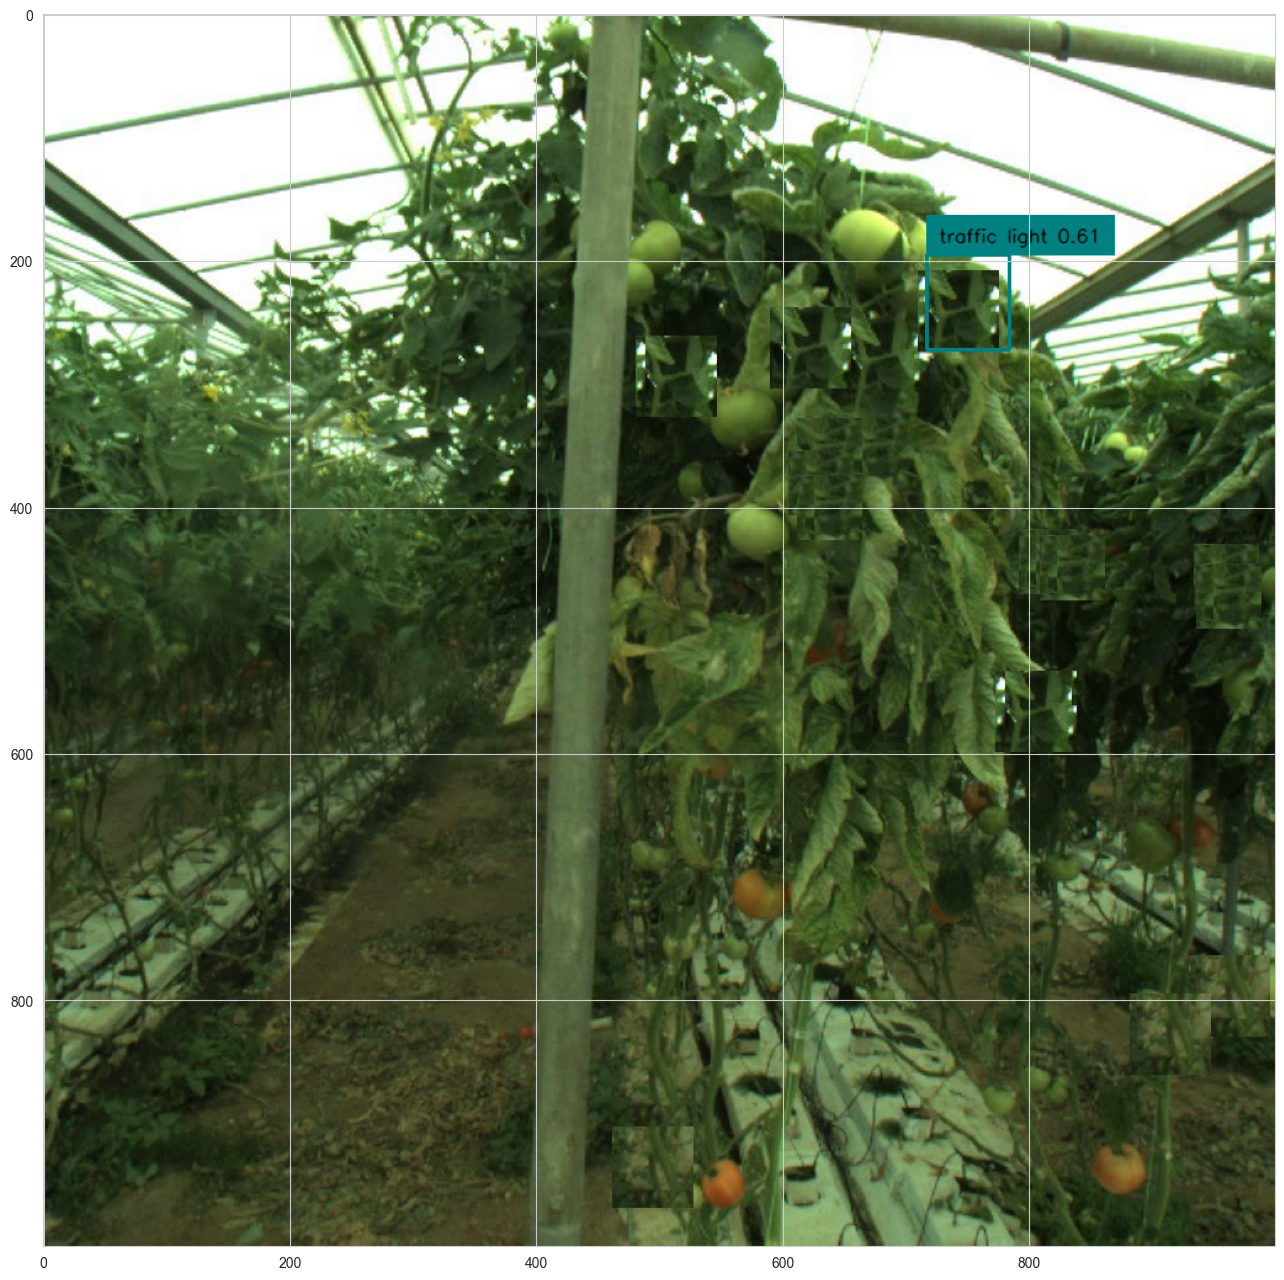

In [ ]:
# root_path = '/root/dataset-ninja/tomatod'
root_path = os.path.join(HOME, "tomatod-DatasetNinja")
train_path = os.path.join(root_path, 'Train/img')

images = os.listdir(train_path)[0]
IMAGE_PATH = os.path.join(train_path, images)
print(IMAGE_PATH)

with torch.no_grad():

    # load image and predict
    image = cv2.imread(IMAGE_PATH)
    inputs = image_processor(images=image, return_tensors='pt').to(DEVICE)
    outputs = model(**inputs)

    # post-process
    target_sizes = torch.tensor([image.shape[:2]]).to(DEVICE)
    results = image_processor.post_process_object_detection(
        outputs=outputs,
        threshold=CONFIDENCE_TRESHOLD,
        target_sizes=target_sizes
    )[0]

# annotate
detections = sv.Detections.from_transformers(transformers_results=results)
# annotate with NMS use the following:
# detections = sv.Detections.from_transformers(transformers_results=results).with_nms(threshold=IOU_TRESHOLD)

# print(detections)

labels = [
    f"{model.config.id2label[class_id]} {confidence:0.2f}"
    for _, confidence, class_id, _
    in detections
]

# print(labels)

# drawing bbox
box_annotator = sv.BoxAnnotator()
frame = box_annotator.annotate(scene=image, detections=detections, labels=labels)

%matplotlib inline
# !pip install --upgrade supervision
sv.show_frame_in_notebook(frame, (16, 16))

這個就沒有很準，很需要finetune。

disply the ground true result

<>:76: SyntaxWarning: invalid escape sequence '\T'
<>:76: SyntaxWarning: invalid escape sequence '\T'
C:\Users\vlva8\AppData\Local\Temp\ipykernel_3696\2354241589.py:76: SyntaxWarning: invalid escape sequence '\T'
  train_path = os.path.join(HOME, "tomatod-DatasetNinja\Train")


image file path: c:\Users\vlva8\OneDrive\Desktop\advML\final_projects\tomatod-DatasetNinja\Train\img\stereo20190406_065607_p0_snap_436.jpg
json file path: c:\Users\vlva8\OneDrive\Desktop\advML\final_projects\tomatod-DatasetNinja\Train\ann\stereo20190406_065607_p0_snap_436.jpg.json
原始圖片大小: 2000x2000
調整後圖片大小: 256x256
物件類別: unripe, bbox: (242, 1268), (314, 1340)
物件類別: fully-ripe, bbox: (220, 1216), (292, 1288)
物件類別: fully-ripe, bbox: (108, 1292), (190, 1374)
物件類別: semi-ripe, bbox: (747, 358), (831, 442)
物件類別: semi-ripe, bbox: (682, 360), (772, 450)
物件類別: fully-ripe, bbox: (1544, 870), (1628, 954)
物件類別: unripe, bbox: (739, 736), (815, 812)
物件類別: semi-ripe, bbox: (2, 1371), (194, 1563)
物件類別: unripe, bbox: (1195, 819), (1277, 901)
物件類別: unripe, bbox: (1648, 1243), (1712, 1307)
物件類別: unripe, bbox: (1586, 1172), (1650, 1236)
物件類別: unripe, bbox: (1308, 1074), (1390, 1156)
物件類別: unripe, bbox: (1130, 855), (1212, 937)
物件類別: unripe, bbox: (27, 598), (197, 768)


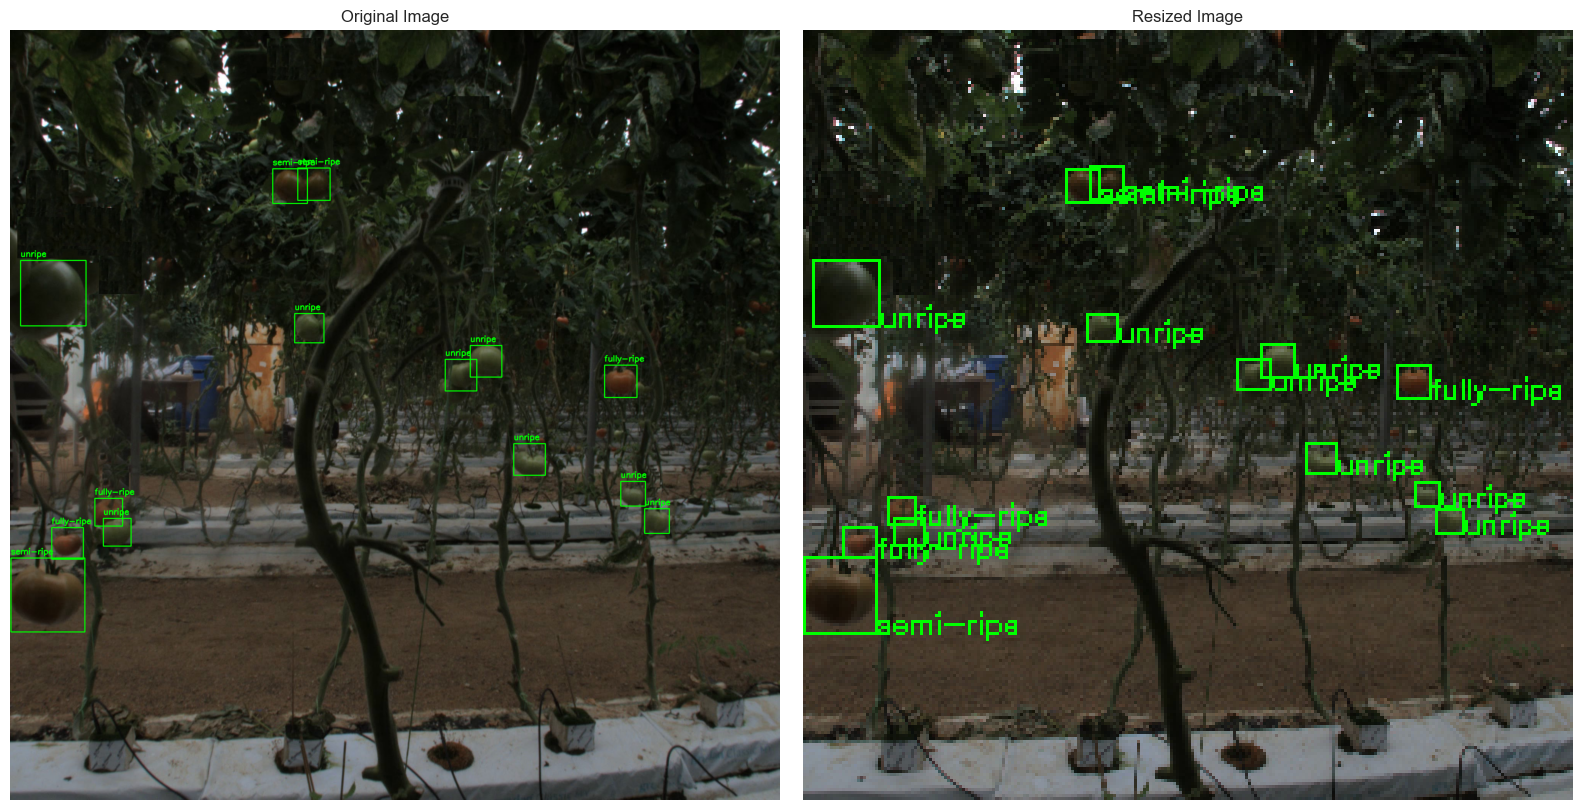

In [7]:
import json

def visualize_annotation(image_path, json_path, resize=None):
    # 讀取圖片
    img = cv2.imread(image_path)
    if img is None:
        print("Error: 讀取圖片失敗")
        return

    # 讀取 annotation JSON
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # 取得原始圖片大小
    img_height, img_width = img.shape[:2]
    print(f"原始圖片大小: {img_width}x{img_height}")
    
    # 複製原圖，以便同時顯示原圖和處理後的圖
    original_img = img.copy()
    
    # 如果需要調整大小
    if resize:
        # 記錄縮放比例，用於調整標註框
        scale_x = resize[0] / img_width
        scale_y = resize[1] / img_height
        img = cv2.resize(img, resize)
        print(f"調整後圖片大小: {resize[0]}x{resize[1]}")
    else:
        scale_x, scale_y = 1.0, 1.0

    # 解析並繪製每個物件的 bbox
    for obj in data['objects']:
        class_name = obj['classTitle']

        # 取得 bbox 左上與右下點座標 (x1,y1), (x2,y2)
        (x1, y1), (x2, y2) = obj['points']['exterior']

        # 印出 bbox 資訊
        print(f"物件類別: {class_name}, bbox: ({x1}, {y1}), ({x2}, {y2})")

        # 繪製矩形框 - 原圖
        pt1_orig = (int(x1), int(y1))
        pt2_orig = (int(x2), int(y2))
        cv2.rectangle(original_img, pt1_orig, pt2_orig, color=(0, 255, 0), thickness=2)
        cv2.putText(original_img, class_name, (pt1_orig[0], pt1_orig[1]-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        
        # 繪製矩形框 - 調整大小後的圖
        pt1 = (int(x1 * scale_x), int(y1 * scale_y))
        pt2 = (int(x2 * scale_x), int(y2 * scale_y))
        cv2.rectangle(img, pt1, pt2, color=(0, 255, 0), thickness=1)
        cv2.putText(img, class_name, (pt2[0], pt2[1]),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.3 , (0, 255, 0), 1)

    # 顯示圖片
    plt.figure(figsize=(16, 8))
    
    # 顯示原圖
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    # 顯示調整大小後的圖片
    plt.subplot(1, 2, 2)
    plt.title("Resized Image" if resize else "Original Image")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# 範例呼叫
if __name__ == "__main__":
    # train_path = '/root/dataset-ninja/tomatod/Train/'
    train_path = os.path.join(HOME, "tomatod-DatasetNinja\Train")
    train_img_path = os.path.join(train_path, "img")
    train_ann_path = os.path.join(train_path, "ann")
    image_path = os.path.join(train_img_path, os.listdir(train_img_path)[-1])
    json_path = os.path.join(train_ann_path, os.listdir(train_img_path)[-1] + ".json")
    print(f"image file path: {image_path}")
    print(f"json file path: {json_path}")
    
    # 顯示原圖和調整大小後的圖片 (例如調整為 800x600)
    visualize_annotation(image_path, json_path, resize=(256, 256))


### Pytorch Dataset

create single coco file

In [ ]:
import json
import os

if not os.path.isdir('./tomatod-DatasetNinja/Train/coco'):
    os.makedirs('./tomatod-DatasetNinja/Train/coco')
if not os.path.isdir('./tomatod-DatasetNinja/Test/coco'):
    os.makedirs('./tomatod-DatasetNinja/Test/coco')

def Generate_COCO_format(root_path, dest_path):
    """
        root_path: the path you want to tranfer to  COCO anntation files
        dest_path: the path you want to stored at
    """
    ann_list = os.listdir(root_path)
    annotation_id = 0

    for image_id, file in enumerate(ann_list):
        # 載入 DatasetNinja 格式
        with open(os.path.join(root_path, file), "r") as f:
            data = json.load(f)

        coco = {
            "images": [],
            "annotations": [],
            "categories": []
        }

        # 圖片資訊（你可能需要加上 filename）
        coco["images"].append({
            "id": image_id,
            "file_name": file[:-5],  # <-- 改成實際檔名
            "width": data["size"]["width"],
            "height": data["size"]["height"]
        })

        # 類別名稱與對應 id
        class_map = {'unripe':0, 'semi-ripe':1, 'fully-ripe':2}
        for k, v in class_map.items():
            coco["categories"].append({
                "id": v,
                "name": k
            })

        # 轉換所有標註
        for obj in data["objects"]:
            class_name = obj["classTitle"]  # 分類結果
            # if class_name not in class_map:
            #     class_map[class_name] = class_id_counter
            #     coco["categories"].append({
            #         "id": class_id_counter,
            #         "name": class_name
            #     })
            #     class_id_counter += 1

            x1, y1 = obj["points"]["exterior"][0]
            x2, y2 = obj["points"]["exterior"][1]
            x, y = x1, y1
            w, h = x2 - x1, y2 - y1

            coco["annotations"].append({
                "id": annotation_id,
                "image_id": image_id,
                "category_id": class_map[class_name],
                "bbox": [x, y, w, h],
                "area": w * h,
                "iscrowd": 0
            })
            annotation_id += 1

        # 儲存為 COCO JSON
        save_path = os.path.join(dest_path, file.replace(".json", "_coco.json"))
        with open(save_path, "w") as f:
            json.dump(coco, f, indent=2)


if __name__ == '__main__':
    train_root = os.path.join(HOME, 'tomatod-DatasetNinja/Train/ann')
    train_coco = os.path.join(HOME, 'tomatod-DatasetNinja/Train/coco')
    Generate_COCO_format(train_root, train_coco)
    test_root = os.path.join(HOME, 'tomatod-DatasetNinja/Test/ann')
    test_coco = os.path.join(HOME, 'tomatod-DatasetNinja/Test/coco')
    Generate_COCO_format(test_root, test_coco)

Create dataset

In [24]:
import json

RESIZE = (256, 256) # image resize size

class TomatoDataset():
    def __init__(self, img_dir, ann_dir, image_processor, label_map=None):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.image_processor = image_processor
        self.image_label_pairs = []

        self.image_files = sorted([f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])

        # 建立類別對應編號
        self.label_map = label_map or {'unripe':0, 'semi-ripe':1, 'fully-ripe':2}

        # 設定 processor resize 的尺寸
        size_dict = {'height': 256, 'width': 256}  # {'height': 256, 'width': 256}
        self.target_size = (size_dict['height'], size_dict['width'])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_filename = self.image_files[idx]
        image_path = os.path.join(self.img_dir, image_filename)
        ann_path = os.path.join(self.ann_dir, image_filename + ".json")

        # 讀圖片
        image = Image.open(image_path).convert("RGB")
        width, height = image.size  # original size
        
        # Convert PIL image to numpy array for cv2 resize
        image_np = np.array(image)
        resized_image = cv2.resize(image_np, RESIZE)
        
        # Convert back to PIL for the image processor
        resized_image_pil = Image.fromarray(resized_image)

        # 預處理
        encoding = self.image_processor(images=resized_image_pil, return_tensors="pt", size={"height": 256, "width": 256})
        pixel_values = encoding["pixel_values"].squeeze(0)

        new_h, new_w = self.target_size
        scale_x = new_w / width
        scale_y = new_h / height

        # 讀標註 + bbox 縮放
        with open(ann_path, "r") as f:
            ann = json.load(f)

        boxes = []
        class_ids = []

        for obj in ann["objects"]:
            class_name = obj["classTitle"]
            class_id = self.label_map[class_name]

            x0, y0 = obj["points"]["exterior"][0]
            x1, y1 = obj["points"]["exterior"][1]
            # ⚠️ 縮放
            x0 *= scale_x
            x1 *= scale_x
            y0 *= scale_y
            y1 *= scale_y

            # xyxy 格式
            boxes.append([x0, y0, x1, y1])
            class_ids.append(class_id)

        # Tensor 轉換
        boxes = torch.tensor(boxes, dtype=torch.float32)
        class_ids = torch.tensor(class_ids, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "class_labels": class_ids,
        }

        return pixel_values, target

# train_root_path = '/root/dataset-ninja/tomatod/Train/img'
# test_root_path = '/root/dataset-ninja/tomatod/Test/img'
train_root_path = os.path.join(HOME, 'tomatod-DatasetNinja/Train/img')
test_root_path = os.path.join(HOME, 'tomatod-DatasetNinja/Test/img')

train_dataset = TomatoDataset(
    # img_dir='/root/dataset-ninja/tomatod/Train/img',
    # ann_dir='/root/dataset-ninja/tomatod/Train/ann',
    img_dir= os.path.join(HOME, 'tomatod-DatasetNinja/Train/img'),
    ann_dir= os.path.join(HOME, 'tomatod-DatasetNinja/Train/ann'),
    image_processor=image_processor
)

# train valid split
train_length=int(0.8* len(train_dataset))
val_length=len(train_dataset)-train_length
train_dataset, val_dataset=torch.utils.data.random_split(train_dataset,(train_length,val_length))

test_dataset = TomatoDataset(
    # img_dir='/root/dataset-ninja/tomatod/Test/img',
    # ann_dir='/root/dataset-ninja/tomatod/Test/ann',
    img_dir= os.path.join(HOME, 'tomatod-DatasetNinja/Test/img'),
    ann_dir= os.path.join(HOME, 'tomatod-DatasetNinja/Test/ann'),
    image_processor=image_processor
)

def collate_fn(batch):
    pixel_values = [item[0] for item in batch]
    encoding = image_processor.pad(pixel_values, return_tensors="pt")
    labels = [item[1] for item in batch]

    # 使用 image_processor 處理
    encoding = image_processor.pad(pixel_values, return_tensors="pt")

    return {
        'pixel_values': encoding['pixel_values'],
        'pixel_mask': encoding['pixel_mask'],
        'labels': labels
    }

train_dataloader = DataLoader(train_dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)
val_dataloader = DataLoader(val_dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

print("Number of training examples:", len(train_dataset))
print("Number of valiational examples:", len(val_dataloader))
print("Number of testing examples:", len(test_dataset))

Number of training examples: 177
Number of valiational examples: 45
Number of testing examples: 55


### finetune

In [9]:
import pytorch_lightning as pl
from transformers import DetrForObjectDetection
import torch

label2id = {'unripe':0, 'semi-ripe':1, 'fully-ripe':2}
id2label = {v: k for k, v in label2id.items()}

class Detr(pl.LightningModule):

    def __init__(self, lr, lr_backbone, weight_decay):
        super().__init__()
        self.model = DetrForObjectDetection.from_pretrained(
            pretrained_model_name_or_path=CHECKPOINT,
            num_labels=len(id2label),
            id2label=id2label,
            label2id={v: k for k, v in id2label.items()},
            ignore_mismatched_sizes=True
        )

        self.lr = lr
        self.lr_backbone = lr_backbone
        self.weight_decay = weight_decay

    def forward(self, pixel_values, pixel_mask):
        if pixel_mask is not None:
            return self.model(pixel_values=pixel_values, pixel_mask=pixel_mask)
        else:
            return self.model(pixel_values=pixel_values)
        # return self.model(pixel_values=pixel_values, pixel_mask=pixel_mask)

    def common_step(self, batch, batch_idx):
        pixel_values = batch["pixel_values"]
        # pixel_mask = batch["pixel_mask"]
        # labels = [{k: v.to(self.device) for k, v in t.items()} for t in batch["labels"]]

        # outputs = self.model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels)

        # DETR 不一定需要 pixel_mask，除非用了 padding
        labels = [{k: v.to(self.device) for k, v in t.items()} for t in batch["labels"]]
        # pixel_mask = batch["pixel_mask"]
        outputs = self.model(pixel_values=pixel_values, labels=labels)

        loss = outputs.loss
        loss_dict = outputs.loss_dict

        return loss, loss_dict

    def training_step(self, batch, batch_idx):
        loss, loss_dict = self.common_step(batch, batch_idx)
        # logs metrics for each training_step, and the average across the epoch
        self.log("training_loss", loss)
        for k,v in loss_dict.items():
            self.log("train_" + k, v.item())

        return loss

    def validation_step(self, batch, batch_idx):
        loss, loss_dict = self.common_step(batch, batch_idx)
        self.log("validation/loss", loss)
        for k, v in loss_dict.items():
            self.log("validation_" + k, v.item())

        # acc
        # outputs = self.model(pixel_values=batch["pixel_values"])
        # preds = outputs.logits.argmax(-1)  # 假設用 argmax 預測類別
        # labels = torch.tensor([label_tensor["class_labels"] for label_tensor in batch["labels"]]).to(self.device)
        # acc = (preds == labels).float().mean()
        # self.log("validation_acc", acc, prog_bar=True)

        return {'val_loss': loss}

    def configure_optimizers(self):
        # DETR authors decided to use different learning rate for backbone
        # you can learn more about it here:
        # - https://github.com/facebookresearch/detr/blob/3af9fa878e73b6894ce3596450a8d9b89d918ca9/main.py#L22-L23
        # - https://github.com/facebookresearch/detr/blob/3af9fa878e73b6894ce3596450a8d9b89d918ca9/main.py#L131-L139
        param_dicts = [
            {
                "params": [p for n, p in self.named_parameters() if "backbone" not in n and p.requires_grad]},
            {
                "params": [p for n, p in self.named_parameters() if "backbone" in n and p.requires_grad],
                "lr": self.lr_backbone,
            },
        ]
        return torch.optim.AdamW(param_dicts, lr=self.lr, weight_decay=self.weight_decay)

    # 訓練跟驗證要用到的
    def train_dataloader(self):
        return train_dataloader

    def val_dataloader(self):
        return val_dataloader

In [13]:
model = Detr(lr=1e-4, lr_backbone=1e-5, weight_decay=1e-4)

batch = next(iter(train_dataloader))
outputs = model(
    pixel_values=batch['pixel_values'],
    pixel_mask=batch.get("pixel_mask", None)
)

Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DetrForObjectDetection were not initialized from the model checkpoin

In [34]:
outputs.logits.shape

torch.Size([8, 100, 4])

In [26]:
from pytorch_lightning import Trainer

%cd {HOME}

# settings
MAX_EPOCHS = 50  # modify at any

# pytorch_lightning < 2.0.0
# trainer = Trainer(gpus=1, max_epochs=MAX_EPOCHS, gradient_clip_val=0.1, accumulate_grad_batches=8, log_every_n_steps=5)

# pytorch_lightning >= 2.0.0
# trainer = Trainer(devices=1, max_epochs=MAX_EPOCHS, gradient_clip_val=0.1, accumulate_grad_batches=8, log_every_n_steps=5)
trainer = Trainer(devices=1, accelerator="gpu", max_epochs=MAX_EPOCHS, gradient_clip_val=0.1, accumulate_grad_batches=8, log_every_n_steps=5)

trainer.fit(model)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


c:\Users\vlva8\OneDrive\Desktop\advML\final_projects


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type                   | Params | Mode
--------------------------------------------------------
0 | model | DetrForObjectDetection | 41.5 M | eval
--------------------------------------------------------
41.3 M    Trainable params
222 K     Non-trainable params
41.5 M    Total params
166.009   Total estimated model params size (MB)
0         Modules in train mode
399       Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

d:\ancode\envs\torch\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:476: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
d:\ancode\envs\torch\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


...

d:\ancode\envs\torch\Lib\site-packages\pytorch_lightning\utilities\data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 1. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


d:\ancode\envs\torch\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch 49: 100%|██████████| 177/177 [01:05<00:00,  2.69it/s, v_num=0]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 177/177 [01:10<00:00,  2.51it/s, v_num=0]


TensorBoard 裡你能看到什麼？
* Lightning 會自動把你在 self.log("val_mAP", mAP) 裡 log 的指標寫入這資料夾

* 你可以看到隨 epoch 變化的曲線（例如 mAP、loss 等）

* 你必須在模型訓練過程中，有 self.log() 這種呼叫才會產生對應數據

* 如果你訓練完了再跑 TensorBoard，它也會顯示所有之前的 log

### Test on test data

In [27]:
model.to(DEVICE)

Detr(
  (model): DetrForObjectDetection(
    (model): DetrModel(
      (backbone): DetrConvModel(
        (conv_encoder): DetrConvEncoder(
          (model): FeatureListNet(
            (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
            (bn1): DetrFrozenBatchNorm2d()
            (act1): ReLU(inplace=True)
            (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
            (layer1): Sequential(
              (0): Bottleneck(
                (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
                (bn1): DetrFrozenBatchNorm2d()
                (act1): ReLU(inplace=True)
                (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
                (bn2): DetrFrozenBatchNorm2d()
                (drop_block): Identity()
                (act2): ReLU(inplace=True)
                (aa): Identity()
                (conv3): Conv2d(64, 256

image_filename:  stereo20190406_054921_p0_snap_330.jpg
torch.Size([3, 256, 256])
Ground Truth


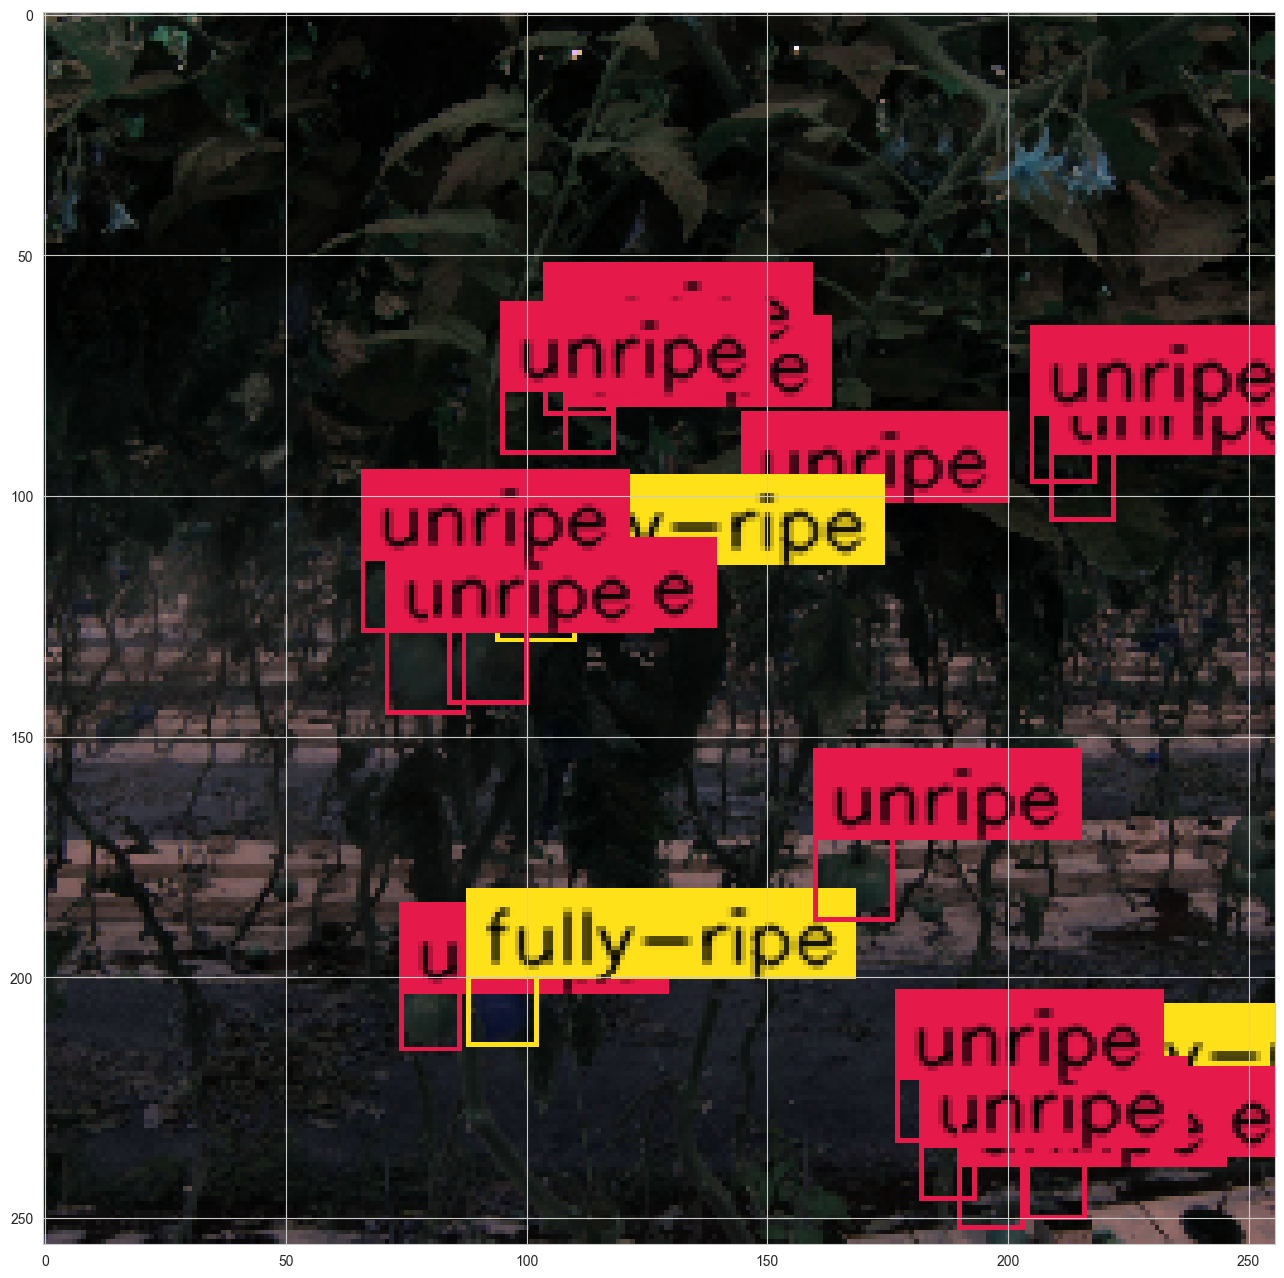

boxes shape: (11, 4)
scores shape: (11,)
class_ids shape: (11,)
Prediction


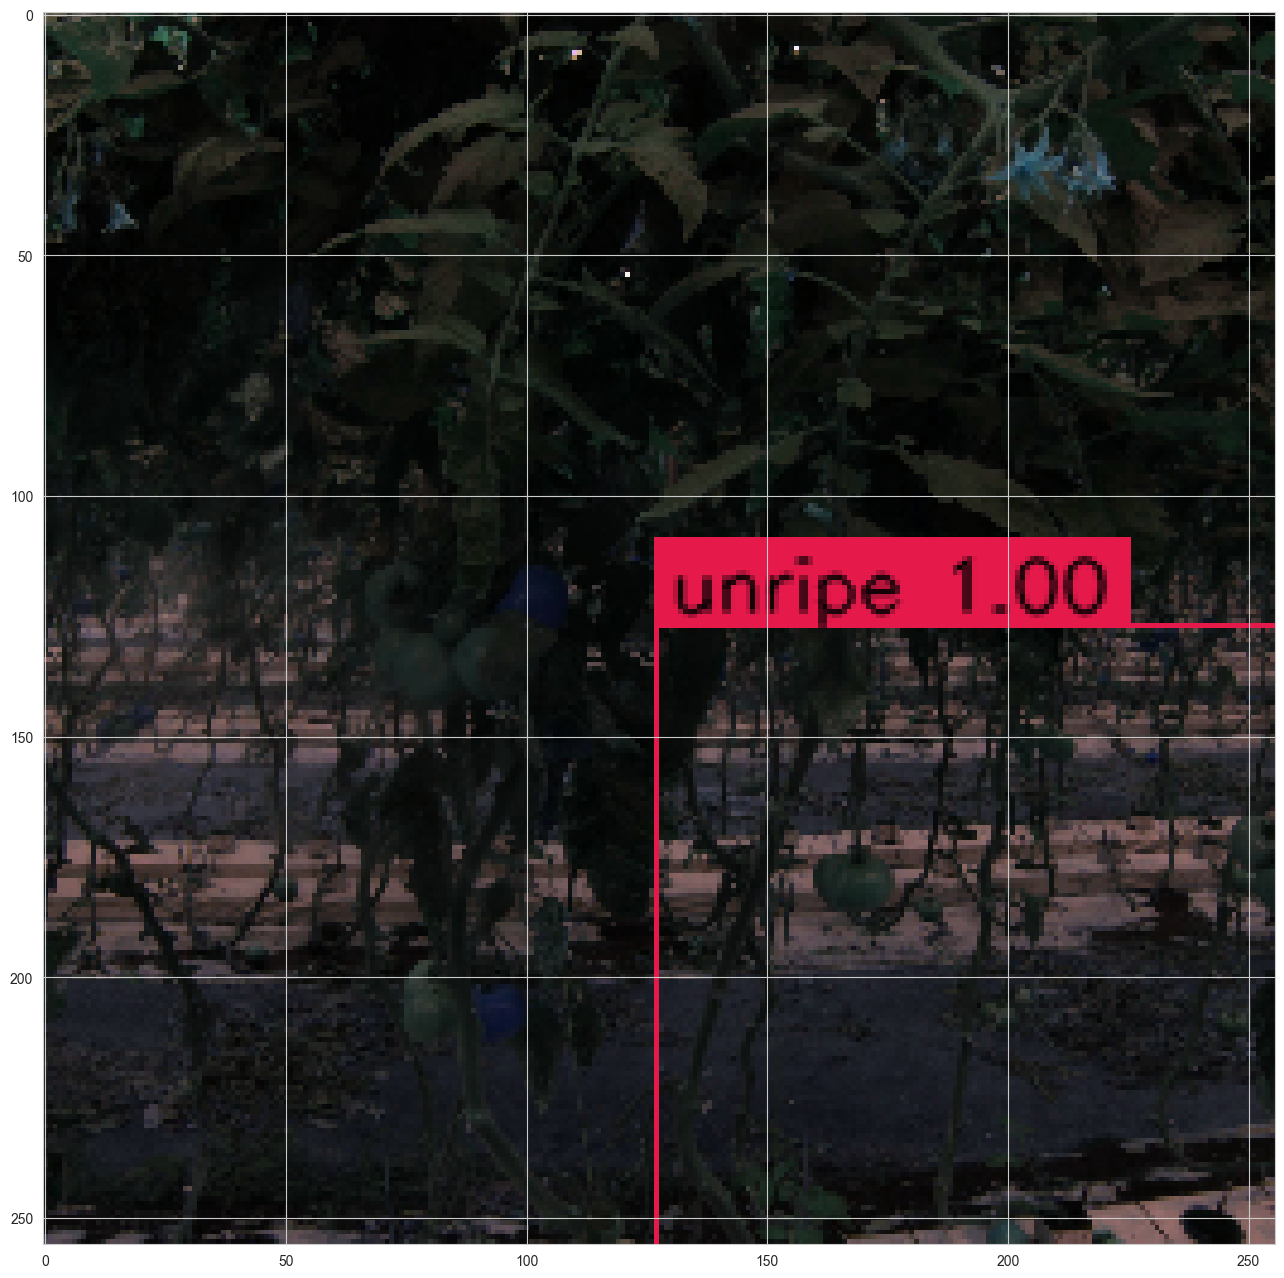

In [30]:
import random
import cv2
import numpy as np
import torch
import supervision as sv

# utils
label2id = {'unripe':0, 'semi-ripe':1, 'fully-ripe':2}
id2label = {v: k for k, v in label2id.items()}
# Create box annotator with smaller text and thinner lines
box_annotator = sv.BoxAnnotator(
    thickness=1,  # thinner lines 
    text_thickness=1,  # thinner text
    text_scale=0.5,  # smaller text
    text_padding=3  # less padding
)

# select random image
index = random.randint(0, len(test_dataset) - 1)
image, target = test_dataset[index]
# print filename
test_img = os.path.join(HOME, 'tomatod-DatasetNinja/Test/img')
print("image_filename: ", os.listdir(test_img)[index])

# --- 處理 image ---
if isinstance(image, torch.Tensor):
    mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
    std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
    image = image * std + mean
    image_np = (image * 255).numpy().transpose(1, 2, 0).astype(np.uint8)

# check image size
print(image.shape[:])

# --- Ground Truth ---
detections_gt = sv.Detections(
    xyxy=target["boxes"].cpu().numpy(),
    class_id=target["class_labels"].cpu().numpy()
)
labels_gt = [f"{id2label[c]}" for c in detections_gt.class_id]
frame_gt = box_annotator.annotate(scene=image_np.copy(), detections=detections_gt, labels=labels_gt)

print("Ground Truth")
%matplotlib inline
sv.show_frame_in_notebook(frame_gt, (16, 16))

# --- Prediction ---
with torch.no_grad():
    inputs = image_processor(images=image_np, return_tensors="pt", do_rescale=True).to(DEVICE)
    outputs = model(**inputs)
    target_sizes = torch.tensor([image_np.shape[:2]]).to(DEVICE)
    results = image_processor.post_process_object_detection(
        outputs=outputs,
        threshold=0.5,
        target_sizes=target_sizes
    )[0]

# 手動建立 Detections
boxes = results["boxes"].cpu().numpy()
scores = results["scores"].cpu().numpy().reshape(-1) if "scores" in results and results["scores"].numel() > 0 else np.array([])
class_ids = results["labels"].cpu().numpy().reshape(-1) if "labels" in results and results["labels"].numel() > 0 else np.array([])

print("boxes shape:", boxes.shape)       # (N, 4)
print("scores shape:", scores.shape)     # (N,)
print("class_ids shape:", class_ids.shape)  # (N,)

if len(boxes) > 0:
    detections_pred = sv.Detections(
        xyxy=boxes,
        confidence=scores,
        class_id=class_ids
    ).with_nms(threshold=0.5)
    
    labels_pred = [f"{id2label[c] if c in id2label else f'unknown-{c}'} {conf:.2f}" for _, conf, c, _ in detections_pred]
    frame_pred = box_annotator.annotate(scene=image_np.copy(), detections=detections_pred, labels=labels_pred)
else:
    print("No detections found above the threshold")
    frame_pred = image_np.copy()

print("Prediction")
%matplotlib inline
sv.show_frame_in_notebook(frame_pred, (16, 16))


這個資料集需要一張圖片找出很多個 bbox，理論上 detr 是一個基於 `prediction set` 的物件偵測模型，應該可以得出類似的結果，但是跑過 300 epochs，模型還沒學好，得到較差的推論結果，推測如下。

| 問題            | 說明           |
| ------------- | --------------------------------------------------------------- |
| ❗小物件居多        | DETR 不擅長小物件，因為不使用 anchor、而是靠 self-attention 掃全圖，會漏掉小目標          |
| ❗資料太少         | 如果你的資料只有幾百張，那 DETR 很容易無法收斂  (ref from [github question](https://github.com/facebookresearch/detr/issues/9), at lease 10K images recommanded)                                      |
| ❗物件密集         | 多個番茄交疊，對 DETR 很難，因為它不預設 anchor 或區域建議                            |
| ❗bbox 對不上     | 若你有 resize 圖片，但 bbox 沒對應縮放，會嚴重導致 loss 高或學不到東西                   |


### Evaluatation
* compared the result with this github repo [link](https://github.com/up2metric/tomatOD)

In [ ]:
!pip install pycocotools

Modified the anntation file into COCO format

In [ ]:
import json
import os

if not os.path.isdir('./tomatod-DatasetNinja/Train/coco_eva'):
    os.makedirs('./tomatod-DatasetNinja/Train/coco_eva')
if not os.path.isdir('./tomatod-DatasetNinja/Test/coco_eva'):
    os.makedirs('./tomatod-DatasetNinja/Test/coco_eva')

def Generate_COCO_eva(root_path, save_path):
    ann_list = os.listdir(root_path)
    annotation_id = 0
    coco = {
        "images": [],
        "annotations": [],
        "categories": []
    }

    # 定義類別
    class_map = {'unripe': 0, 'semi-ripe': 1, 'fully-ripe': 2}
    for name, id_ in class_map.items():
        coco["categories"].append({"id": id_, "name": name})

    for image_id, file in enumerate(ann_list):
        with open(os.path.join(root_path, file), "r") as f:
            data = json.load(f)

        coco["images"].append({
            "id": image_id,
            "file_name": file[:-5],  # <-- 改成實際檔名
            "width": data["size"]["width"],
            "height": data["size"]["height"]
        })

        for obj in data["objects"]:
            class_id = class_map[obj["classTitle"]]
            x1, y1 = obj["points"]["exterior"][0]
            x2, y2 = obj["points"]["exterior"][1]
            x, y = x1, y1
            w, h = x2 - x1, y2 - y1

            coco["annotations"].append({
                "id": annotation_id,
                "image_id": image_id,
                "category_id": class_id,
                "bbox": [x, y, w, h],
                "area": w * h,
                "iscrowd": 0
            })
            annotation_id += 1

    
    # 補一個基本描述）
    coco["info"] = {
        "description": "Tomato detection dataset",
        "version": "1.0",
        "year": 2025
    }
    # 存成單一 JSON
    with open(save_path, "w") as f:
        json.dump(coco, f, indent=2)


if __name__ == '__main__':
    train_root = os.path.join(HOME, 'tomatod-DatasetNinja/Train/ann')
    train_coco = os.path.join(HOME, 'tomatod-DatasetNinja/Train/coco_eva/train_ann.json')
    Generate_COCO_eva(train_root, train_coco)
    test_root = os.path.join(HOME, 'tomatod-DatasetNinja/Test/ann')
    test_coco = os.path.join(HOME, 'tomatod-DatasetNinja/Test/coco_eva/test_ann.json')
    Generate_COCO_eva(test_root, test_coco)

In [102]:
import torch
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from tqdm import tqdm
import json

# --- 參數設定 ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model.to(DEVICE)
model.eval()

# --- 讀入 GT 的 annotations.json ---
coco_gt = COCO(test_coco)

# --- 建立 filename 對應到 image_id & size 的對照表 ---
file2id_size = {
    img["file_name"]: (img["id"], (img["height"], img["width"]))
    for img in coco_gt.dataset["images"]
}

# --- 預測結果儲存用 ---
all_predictions = []

# --- 開始推論 + 收集 coco 格式結果 ---
for idx, batch in enumerate(tqdm(test_dataloader)):
    pixel_values = batch["pixel_values"].to(DEVICE)
    pixel_mask = batch["pixel_mask"].to(DEVICE)
    
    # 推論
    with torch.no_grad():
        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)

    # 根據 test_dataset 取得 filename → image_id & size
    filename = test_dataset.image_files[idx]
    image_id, (h, w) = file2id_size[filename]

    # 後處理
    orig_target_sizes = torch.tensor([[h, w]], device=DEVICE)
    results = image_processor.post_process_object_detection(outputs, target_sizes=orig_target_sizes, threshold=0.5)[0]

    # 轉成 COCO format
    boxes = results["boxes"].cpu().tolist()  # xyxy
    scores = results["scores"].cpu().tolist()
    labels = results["labels"].cpu().tolist()

    # xyxy → xywh
    def xyxy_to_xywh(box):
        x_min, y_min, x_max, y_max = box
        return [x_min, y_min, x_max - x_min, y_max - y_min]

    for b, s, l in zip(boxes, scores, labels):
        all_predictions.append({
            "image_id": image_id,
            "category_id": l,
            "bbox": xyxy_to_xywh(b),
            "score": s
        })

# --- 儲存推論結果 ---
with open("results.json", "w") as f:
    json.dump(all_predictions, f, indent=2)

# --- 評估 ---
coco_dt = coco_gt.loadRes("results.json")
evaluator = COCOeval(coco_gt, coco_dt, iouType="bbox")
evaluator.evaluate()
evaluator.accumulate()
evaluator.summarize()


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


  0%|          | 0/55 [00:00<?, ?it/s]

100%|██████████| 55/55 [00:11<00:00,  4.66it/s]


Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.33s).
Accumulating evaluation results...
DONE (t=0.05s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

save the model

In [69]:
MODEL_PATH = os.path.join(HOME, 'custom-model')

In [70]:
model.model.save_pretrained(MODEL_PATH)

load the model

In [71]:
model = DetrForObjectDetection.from_pretrained(MODEL_PATH)
model.to(DEVICE)

d:\ancode\envs\torch\Lib\site-packages\torch\nn\modules\module.py:2409: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
d:\ancode\envs\torch\Lib\site-packages\torch\nn\modules\module.py:2409: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
d:\ancode\envs\torch\Lib\site-packages\torch\nn\modules\module.py:2409: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `

DetrForObjectDetection(
  (model): DetrModel(
    (backbone): DetrConvModel(
      (conv_encoder): DetrConvEncoder(
        (model): FeatureListNet(
          (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
          (bn1): DetrFrozenBatchNorm2d()
          (act1): ReLU(inplace=True)
          (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          (layer1): Sequential(
            (0): Bottleneck(
              (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn1): DetrFrozenBatchNorm2d()
              (act1): ReLU(inplace=True)
              (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (bn2): DetrFrozenBatchNorm2d()
              (drop_block): Identity()
              (act2): ReLU(inplace=True)
              (aa): Identity()
              (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      